# Grid Line Detection — Interactive Evaluation Notebook

Use this notebook to inspect how well the agent reads grid lines from your floor plan PDF,
record corrections, and re-run with correction memory active.

**Workflow:**
1. Set `PDF_PATH` in Section 0
2. Run Sections 1–6 to evaluate the raw detection
3. Use Section 8 to record a correction if anything is wrong
4. Run Section 9 to see the correction-informed re-run

**Restart & Run All** to evaluate from scratch.

## Section 0 — Setup

Set `PDF_PATH` to your floor plan file, then run all cells.

In [5]:
import sys, os, json, warnings
warnings.filterwarnings('ignore')

# ── USER CONFIGURATION ────────────────────────────────────────
PDF_PATH = "/home/jiezhi/Documents/floor-plan-pdf/84f2df7c-3ddc-4516-bdd8-090cfe5e5c93.pdf"   # ← SET THIS
# ─────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from PIL import Image

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

SEALION_ONLINE = True
try:
    import ollama_client
    import pdf_renderer
    import agent
    import tools
    print("✓ All modules loaded.")
except RuntimeError as e:
    SEALION_ONLINE = False
    print(f"⚠ SEA-LION is offline: {e}")
    print("Vision sections will be skipped. Fix Ollama and re-run.")

if not os.path.isfile(PDF_PATH):
    print(f"⚠ PDF not found: {PDF_PATH}")
    print("Update PDF_PATH in Section 0 and re-run.")

_state = {}
print("Setup complete.")

✓ All modules loaded.
Setup complete.


## Section 1 — Raw Floor Plan Preview

Render all pages and display them so you can confirm you have the right PDF.

Rendering PDF at 150 DPI for preview...
Pages: 1
  Page 1: 807 x 766 px


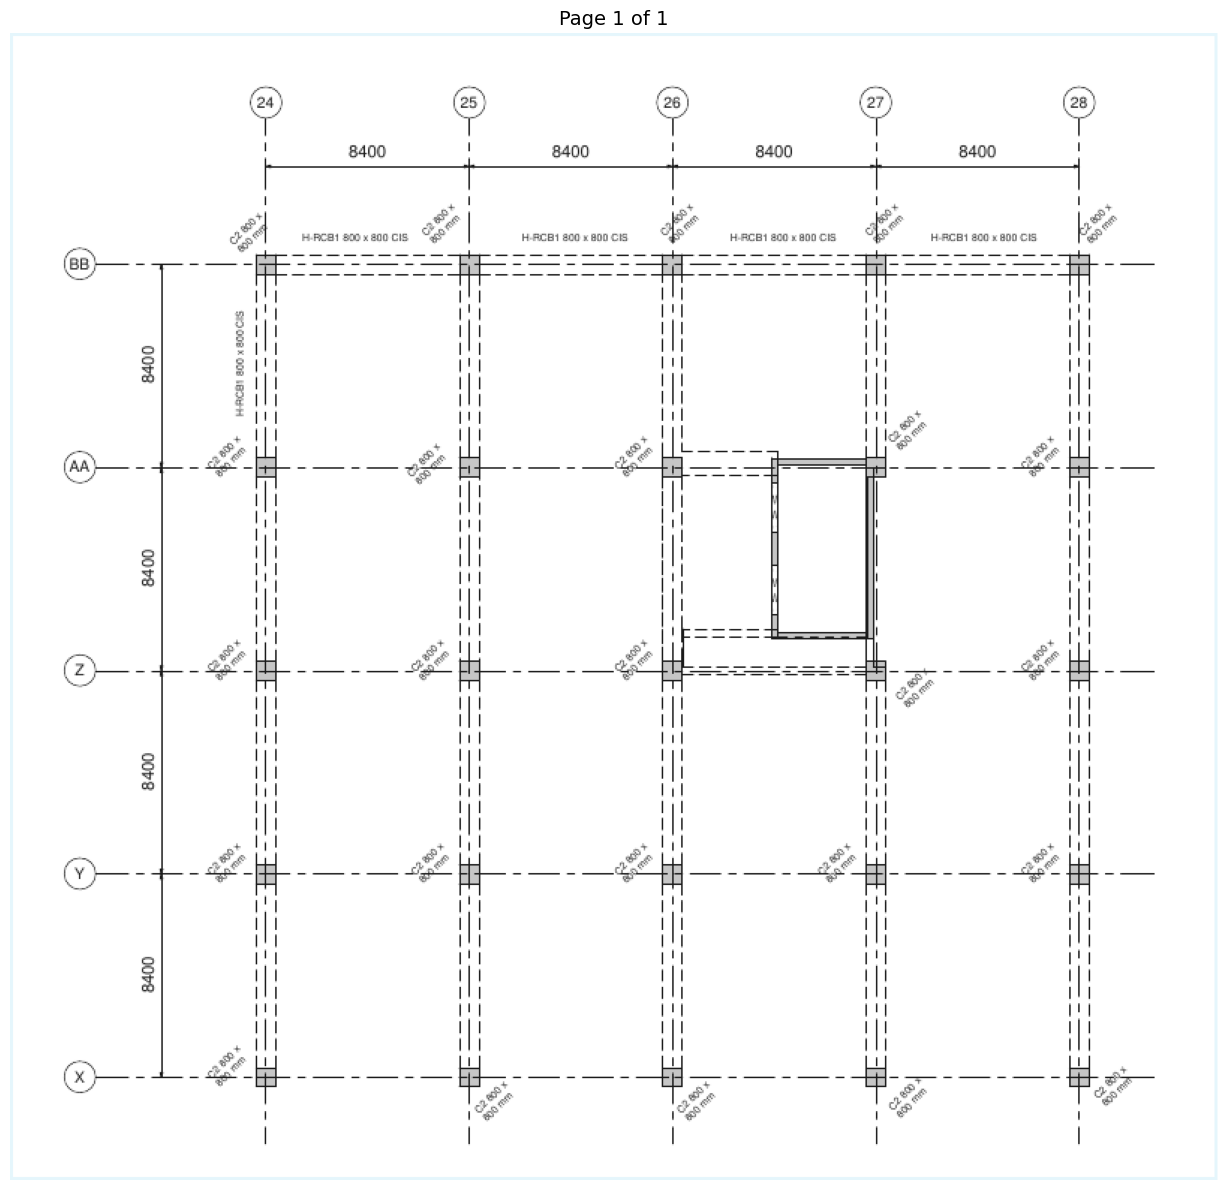

In [6]:
if not os.path.isfile(PDF_PATH):
    print("⚠ PDF not found — skipping.")
else:
    print("Rendering PDF at 150 DPI for preview...")
    preview_images = pdf_renderer.pdf_to_images(PDF_PATH, dpi=150)
    _state['preview_images'] = preview_images
    page_count = len(preview_images)
    print(f"Pages: {page_count}")

    for i, img_path in enumerate(preview_images):
        img = Image.open(img_path)
        w, h = img.size
        print(f"  Page {i+1}: {w} x {h} px")
        fig, ax = plt.subplots(figsize=(16, 12))
        ax.imshow(img)
        ax.set_title(f"Page {i+1} of {page_count}", fontsize=14)
        ax.axis('off')
        plt.tight_layout()
        plt.show()

## Section 2 — Initial Detection (Single Pass)

What SEA-LION sees on a first look, before any verification or margin scanning.

📌 Correction memory found for this PDF:
   Vertical:   ['1', '2', '3', '4', '5']
   Horizontal: ['A', 'B', 'C', 'D']

Running initial detection (no correction hint)...


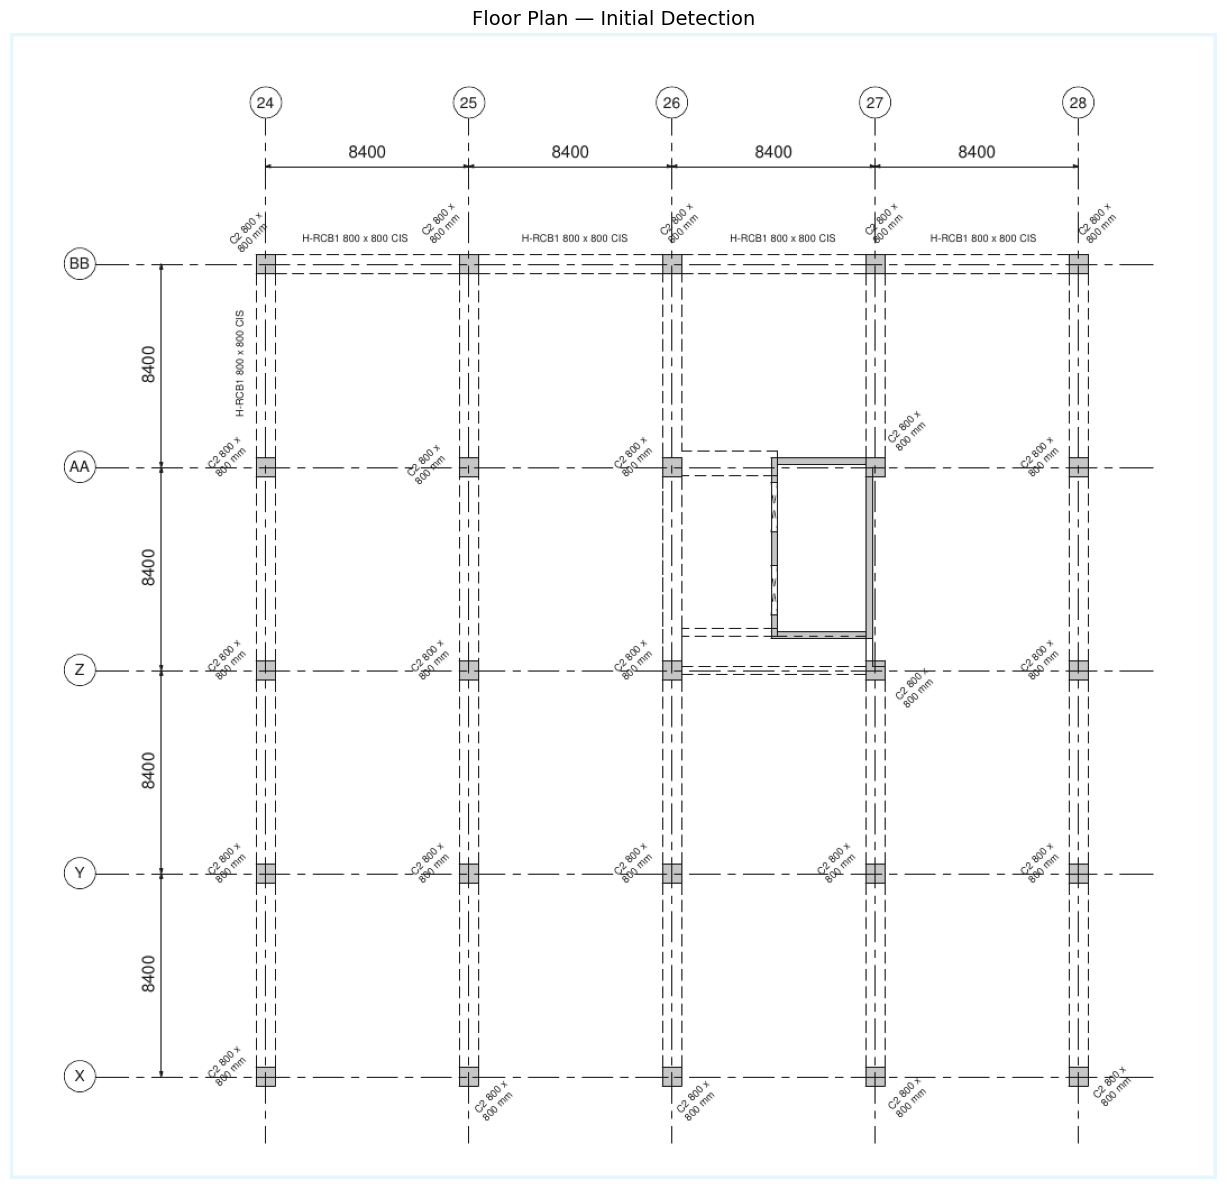


── Initial Detection Result ──────────────────────
{
  "total_grid_lines": 27,
  "vertical_labels": [
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9",
    "10",
    "11",
    "12",
    "13",
    "14",
    "15",
    "16",
    "17",
    "18",
    "19",
    "20",
    "21",
    "22",
    "23",
    "24",
    "25"
  ],
  "horizontal_labels": [
    "A",
    "B",
    "C",
    "D",
    "E",
    "F",
    "G",
    "H",
    "I",
    "J",
    "K",
    "L",
    "M",
    "N",
    "O",
    "P",
    "Q",
    "R",
    "S",
    "T",
    "U",
    "V"
  ],
  "confidence": 1.0,
  "notes": ""
}


In [17]:
if not SEALION_ONLINE or not os.path.isfile(PDF_PATH):
    print("⚠ Skipping (SEA-LION offline or PDF missing).")
else:
    images_200 = pdf_renderer.pdf_to_images(PDF_PATH, dpi=200)
    _state['images_200'] = images_200
    floor_plan_image = agent._select_floor_plan_page(images_200, verbose=True)
    _state['floor_plan_image'] = floor_plan_image

    # Check if a correction exists — show it before detecting
    correction = tools.tool_memory_lookup(PDF_PATH)
    if correction:
        print(f"📌 Correction memory found for this PDF:")
        print(f"   Vertical:   {correction['vertical_labels']}")
        print(f"   Horizontal: {correction['horizontal_labels']}")
        if correction.get('notes'):
            print(f"   Notes: {correction['notes']}")
        print()

    print("Running initial detection (no correction hint)...")
    initial = tools.tool_detect_grid(floor_plan_image, agent.SYSTEM_PROMPT)
    _state['initial'] = initial

    fig, ax = plt.subplots(figsize=(16, 12))
    ax.imshow(Image.open(floor_plan_image))
    ax.set_title("Floor Plan — Initial Detection", fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    print("\n── Initial Detection Result ──────────────────────")
    print(json.dumps(initial, indent=2))

## Section 3 — Verification Pass

SEA-LION checks its own answer. Differences between passes reveal uncertainty.

In [8]:
if not SEALION_ONLINE or 'initial' not in _state:
    print("⚠ Skipping (SEA-LION offline or Section 2 not run).")
else:
    print("Running verification pass...")
    verified = tools.tool_verify(_state['floor_plan_image'], _state['initial'], agent.VERIFICATION_PROMPT)
    _state['verified'] = verified

    initial = _state['initial']

    def _fmt(v):
        return ' '.join(str(x) for x in v) if isinstance(v, list) else str(v)

    fields = ['total_grid_lines', 'vertical_labels', 'horizontal_labels', 'confidence']
    print(f"\n{'Field':<25} {'Initial':<35} {'Verified':<35} {'Status'}")
    print("-" * 105)
    for f in fields:
        a = _fmt(initial.get(f))
        b = _fmt(verified.get(f))
        status = "✓ Matched" if a == b else "⚠ Changed"
        print(f"{f:<25} {a:<35} {b:<35} {status}")

    print(f"\nNotes (initial):  {initial.get('notes', '')}")
    print(f"Notes (verified): {verified.get('notes', '')}")

Running verification pass...

Field                     Initial                             Verified                            Status
---------------------------------------------------------------------------------------------------------
total_grid_lines          27                                  27                                  ✓ Matched
vertical_labels           1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 ✓ Matched
horizontal_labels         A B C D E F G H I J K L M N O P Q R S T U V W X Y Z A B C D E F G H I J K L M N O P Q R S T U V W X Y Z ✓ Matched
confidence                1.0                                 1.0                                 ✓ Matched

Notes (initial):  
Notes (verified): All labels are present and appear consistently on both sides of the drawing (top/bottom and left/right). No adjustments needed.


## Section 4 — Margin Scans

Crop each margin band and inspect what SEA-LION reads there individually.

Scanning top margin...
Scanning bottom margin...
Scanning left margin...
Scanning right margin...


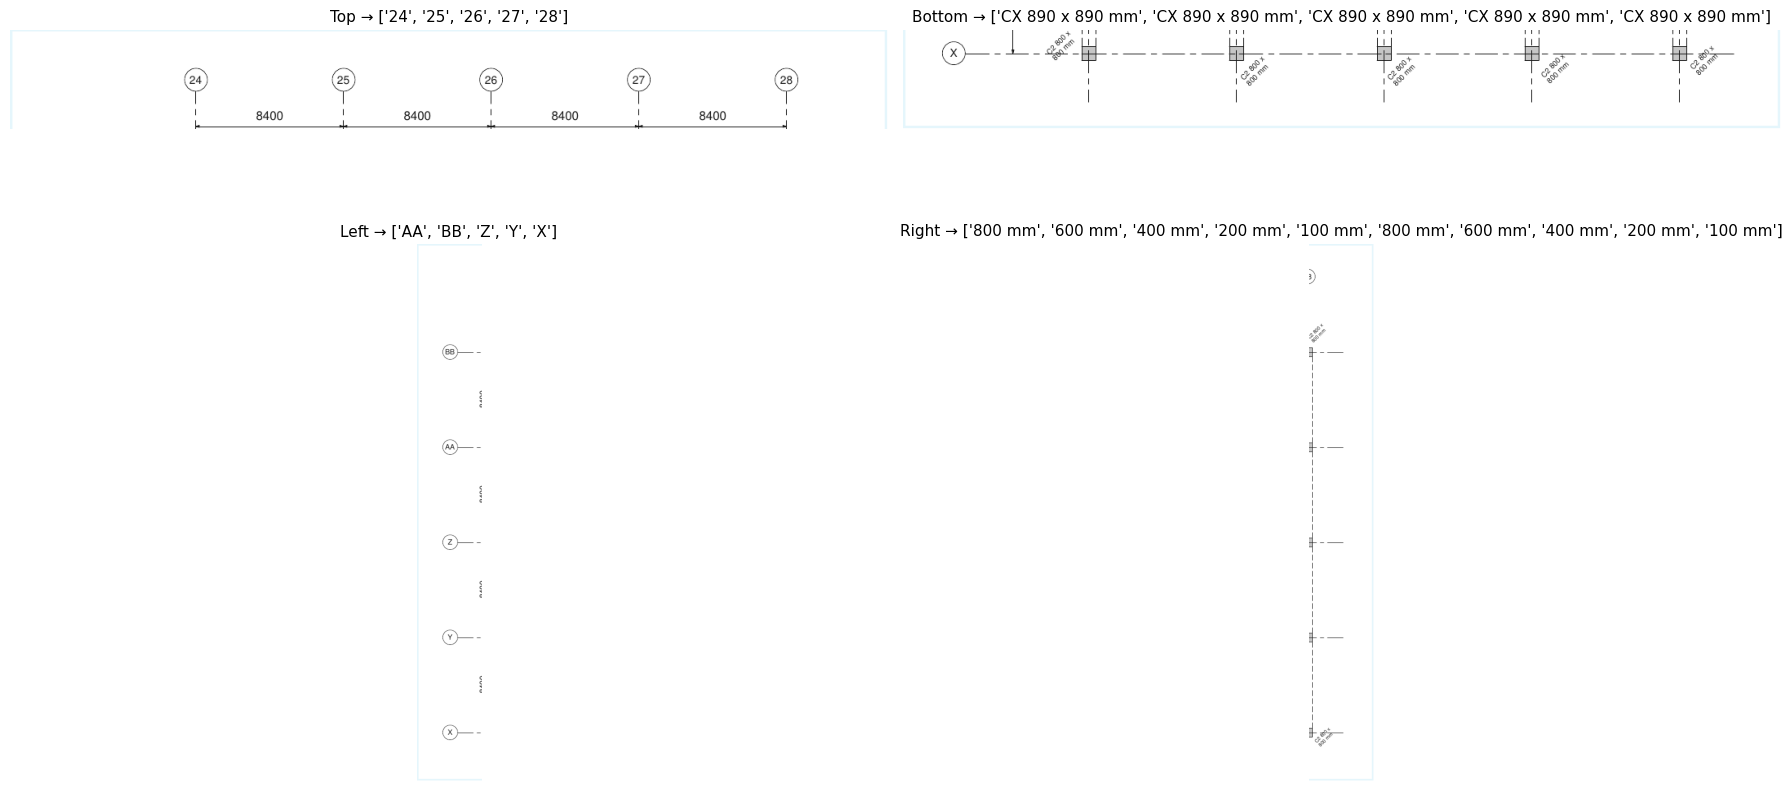


── Margin Label Summary ─────────────────────────
Margin     Labels Found
--------------------------------------------------
Top        24 25 26 27 28
Bottom     CX 890 x 890 mm CX 890 x 890 mm CX 890 x 890 mm CX 890 x 890 mm CX 890 x 890 mm
Left       AA BB Z Y X
Right      800 mm 600 mm 400 mm 200 mm 100 mm 800 mm 600 mm 400 mm 200 mm 100 mm

── Opposing Margin Consistency ──────────────────
  top/bottom: ⚠ differ → ['24', '25', '26', '27', '28', 'CX 890 x 890 mm']
  left/right: ⚠ differ → ['100 mm', '200 mm', '400 mm', '600 mm', '800 mm', 'AA', 'BB', 'X', 'Y', 'Z']


In [9]:
if not SEALION_ONLINE or 'floor_plan_image' not in _state:
    print("⚠ Skipping (SEA-LION offline or floor plan image not available).")
else:
    img = Image.open(_state['floor_plan_image'])
    w, h = img.size
    band = int(tools.MARGIN_FRACTION * min(w, h))

    boxes = {
        'top':    (0, 0, w, band),
        'bottom': (0, h - band, w, h),
        'left':   (0, 0, band, h),
        'right':  (w - band, 0, w, h),
    }

    margin_results = {}
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    ax_map = {'top': axes[0,0], 'bottom': axes[0,1], 'left': axes[1,0], 'right': axes[1,1]}

    for side in ('top', 'bottom', 'left', 'right'):
        print(f"Scanning {side} margin...")
        scan = tools.tool_zoom_margin(_state['floor_plan_image'], side, agent.ZOOMED_PROMPT)
        margin_results[side] = scan['labels']
        crop = img.crop(boxes[side])
        ax = ax_map[side]
        ax.imshow(crop)
        ax.set_title(f"{side.capitalize()} → {scan['labels']}", fontsize=11)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
    _state['margin_results'] = margin_results

    print("\n── Margin Label Summary ─────────────────────────")
    print(f"{'Margin':<10} {'Labels Found'}")
    print("-" * 50)
    for side in ('top', 'bottom', 'left', 'right'):
        labels = ' '.join(margin_results[side]) if margin_results[side] else '(none)'
        print(f"{side.capitalize():<10} {labels}")

    print("\n── Opposing Margin Consistency ──────────────────")
    for a, b in [('top', 'bottom'), ('left', 'right')]:
        la = sorted(margin_results.get(a, []))
        lb = sorted(margin_results.get(b, []))
        if la == lb:
            print(f"  {a}/{b}: ✓ consistent")
        else:
            diff = set(la).symmetric_difference(set(lb))
            print(f"  {a}/{b}: ⚠ differ → {sorted(diff)}")

## Section 5 — Full Agent Run

End-to-end run of the complete agentic workflow with verbose logging.

Running full agent...
  [agent] === Attempt 1 (DPI=200) ===
  [agent] Step 1: Rendering PDF to images.
  [agent]   Rendered 1 page(s).
  [agent]   Using image: page_001.png
  [agent] Step 2: Initial grid detection.
  [agent]   Initial: 27 lines, confidence=1.00
  [agent] Step 3: Verification pass.
  [agent]   Discrepancy detected.
  [agent]   Verified: 27 lines, confidence=1.00
  [agent] Step 4: Margin scan (low confidence or discrepancy).
  [agent]   Left margin: ['AA', 'BB', 'Z', 'Y', 'X']
  [agent]   Top margin: ['24', '25', '26', '27', '28']
  [agent]   Right margin: ['800 mm', '800 mm', '800 mm']
  [agent]   Bottom margin: ['C1 800 x 800 mm', 'C1 800 x 800 mm', 'C1 800 x 800 mm', 'C1 800 x 800 mm', 'C1 800 x 800 mm']
  [agent]   Reconciling full detection with margin scans.
  [agent]   Reconciled: 27 lines, confidence=1.00
  [agent] Step 5: Skipped (confidence is sufficient).
  [agent] Step 6: Confidence 1.00 >= 0.85. Done.

── Final JSON Result ─────────────────────────────
{
  "

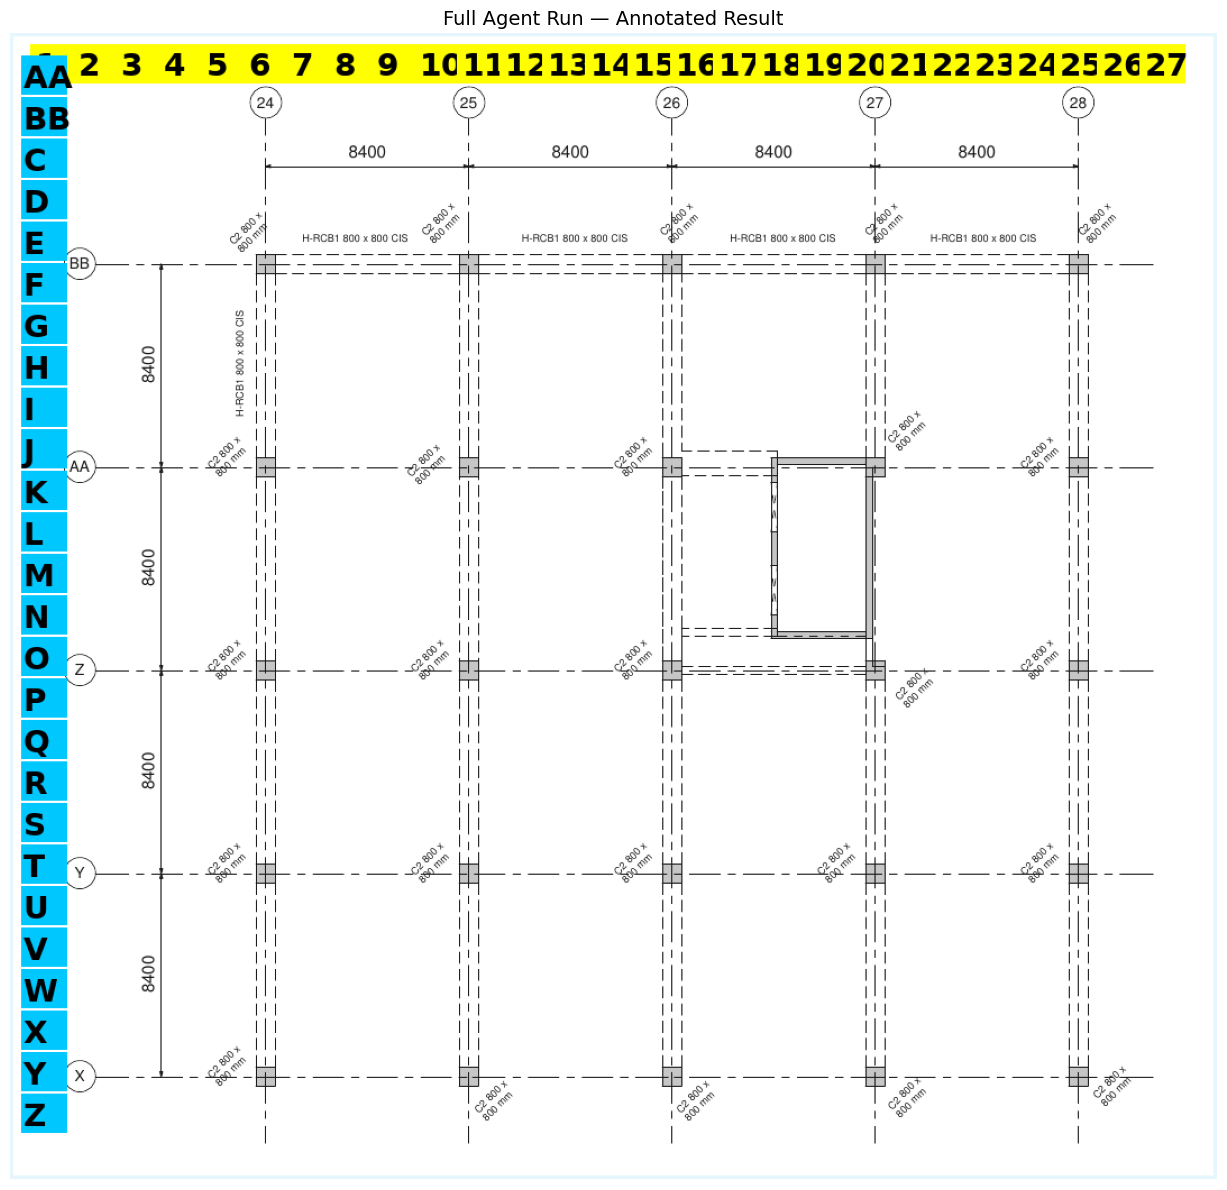

In [10]:
if not SEALION_ONLINE or not os.path.isfile(PDF_PATH):
    print("⚠ Skipping (SEA-LION offline or PDF missing).")
else:
    print("Running full agent...")
    print("=" * 60)
    full_result = agent.run(PDF_PATH, verbose=True)
    _state['full_result'] = full_result

    print("=" * 60)
    print("\n── Final JSON Result ─────────────────────────────")
    display_result = {k: v for k, v in full_result.items()
                      if k not in ('steps_taken', '_rendered_image')}
    print(json.dumps(display_result, indent=2))

    # Annotated image preview
    try:
        from PIL import ImageDraw, ImageFont
        img_path = full_result.get('_rendered_image') or _state['images_200'][0]
        img = Image.open(img_path).convert('RGB')
        draw = ImageDraw.Draw(img)
        w, h = img.size
        try:
            font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 28)
        except IOError:
            font = ImageFont.load_default()

        for i, lbl in enumerate(full_result.get('vertical_labels', [])):
            n = len(full_result['vertical_labels'])
            x = (w // (n + 1)) * (i + 1)
            draw.rectangle([x-20, 10, x+20, 44], fill=(255,255,0))
            draw.text((x-15, 12), lbl, fill=(0,0,0), font=font)

        for i, lbl in enumerate(full_result.get('horizontal_labels', [])):
            n = len(full_result['horizontal_labels'])
            y = (h // (n + 1)) * (i + 1)
            draw.rectangle([10, y-17, 50, y+17], fill=(0,200,255))
            draw.text((12, y-14), lbl, fill=(0,0,0), font=font)

        fig, ax = plt.subplots(figsize=(16, 12))
        ax.imshow(img)
        ax.set_title("Full Agent Run — Annotated Result", fontsize=14)
        ax.axis('off')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"(Annotation preview skipped: {e})")

## Section 6 — Detection Summary

Formatted summary table of all detection passes.

In [11]:
if 'full_result' not in _state:
    print("⚠ Skipping (run Section 5 first).")
else:
    fr   = _state['full_result']
    init = _state.get('initial', {})
    ver  = _state.get('verified', {})
    mr   = _state.get('margin_results', {})

    v_labels = ' '.join(fr.get('vertical_labels', [])) or '(none)'
    h_labels = ' '.join(fr.get('horizontal_labels', [])) or '(none)'
    v_count  = len(fr.get('vertical_labels', []))
    h_count  = len(fr.get('horizontal_labels', []))
    total    = fr.get('total_grid_lines', 0)
    conf     = fr.get('confidence', 0)
    retries  = len([s for s in fr.get('steps_taken', []) if 'Attempt' in s])

    init_total = init.get('total_grid_lines', 'N/A')
    ver_total  = ver.get('total_grid_lines', 'N/A')
    ver_note   = '(no change)' if init_total == ver_total else f'(changed from {init_total})'
    margin_note = 'skipped (confident)' if not mr else 'completed'
    used_hint  = '✓ yes' if fr.get('used_reference_hint') else 'no'
    used_mem   = '✓ yes' if fr.get('used_correction_memory') else 'no'

    W = 56
    def row(label, value):
        lw = 32
        return f"║ {label:<{lw}} ║ {str(value):<{W-lw-5}} ║"

    sep = '╠' + '═'*34 + '╬' + '═'*(W-34-1) + '╣'
    top = '╔' + '═'*34 + '╦' + '═'*(W-34-1) + '╗'
    bot = '╚' + '═'*34 + '╩' + '═'*(W-34-1) + '╝'

    print(top)
    print('║' + ' GRID LINE DETECTION SUMMARY'.center(W) + '║')
    print(sep)
    print(row('Total grid lines detected', total))
    print(sep)
    print(row(f'Vertical lines  ({v_count})', f'→  {v_labels}'))
    print(row(f'Horizontal lines  ({h_count})', f'→  {h_labels}'))
    print(sep)
    print(row('Initial detection', init_total))
    print(row('After verification', f'{ver_total}  {ver_note}'))
    print(row('After margin scan', margin_note))
    print(sep)
    print(row('Agent confidence', f'{conf:.2f}'))
    print(row('Retries', retries))
    print(row('Used reference hint', used_hint))
    print(row('Used correction memory', used_mem))
    print(bot)

╔══════════════════════════════════╦═════════════════════╗
║               GRID LINE DETECTION SUMMARY              ║
╠══════════════════════════════════╬═════════════════════╣
║ Total grid lines detected        ║ 53                  ║
╠══════════════════════════════════╬═════════════════════╣
║ Vertical lines  (27)             ║ →  1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 ║
║ Horizontal lines  (26)           ║ →  AA BB C D E F G H I J K L M N O P Q R S T U V W X Y Z ║
╠══════════════════════════════════╬═════════════════════╣
║ Initial detection                ║ 27                  ║
║ After verification               ║ 27  (no change)     ║
║ After margin scan                ║ completed           ║
╠══════════════════════════════════╬═════════════════════╣
║ Agent confidence                 ║ 1.00                ║
║ Retries                          ║ 1                   ║
║ Used reference hint              ║ no                  ║
║ Used correction memor

## Section 7 — Improvement Areas

Auto-generated findings based on the actual run results.

In [12]:
if 'full_result' not in _state:
    print("⚠ Skipping (run Section 5 first).")
else:
    fr   = _state['full_result']
    init = _state.get('initial', {})
    ver  = _state.get('verified', {})
    mr   = _state.get('margin_results', {})
    findings = []
    conf = float(fr.get('confidence', 0))

    if conf < 0.85:
        findings.append(
            f"Confidence LOW ({conf:.2f}). Review margin scans in Section 4. "
            "Consider recording a correction in Section 8 — the agent will use it next run."
        )

    if init and ver:
        iv = sorted(init.get('vertical_labels', []))
        vv = sorted(ver.get('vertical_labels', []))
        ih = sorted(init.get('horizontal_labels', []))
        vh = sorted(ver.get('horizontal_labels', []))
        inconsistent = list(set(iv).symmetric_difference(set(vv)) |
                           set(ih).symmetric_difference(set(vh)))
        if inconsistent:
            findings.append(
                f"SEA-LION changed its answer between passes. "
                f"Inconsistent labels: {sorted(set(inconsistent))}. "
                "Try higher DPI or record a correction to lock in the right answer."
            )

    if mr:
        for a, b in [('top', 'bottom'), ('left', 'right')]:
            la = sorted(mr.get(a, []))
            lb = sorted(mr.get(b, []))
            if la != lb:
                diff = sorted(set(la).symmetric_difference(set(lb)))
                findings.append(
                    f"Margins {a.upper()} and {b.upper()} disagree: {diff}. "
                    "Inspect Section 4 crops manually."
                )

    uncertain = [lbl for lbl in
                 fr.get('vertical_labels', []) + fr.get('horizontal_labels', [])
                 if '?' in str(lbl)]
    if uncertain:
        findings.append(
            f"{len(uncertain)} label(s) flagged uncertain: {uncertain}. "
            "Inspect margin crops in Section 4."
        )

    retries = len([s for s in fr.get('steps_taken', []) if 'Attempt' in s])
    if retries > 1:
        findings.append(
            f"Agent retried {retries} time(s). Consider recording a correction "
            "in Section 8 to avoid repeated low-confidence runs on this PDF."
        )

    if fr.get('used_reference_hint'):
        findings.append(
            "Agent used the reference notebook hint (last resort). "
            "Record a correction in Section 8 to avoid this next time."
        )

    print("## Improvement Areas")
    print("=" * 60)
    if not findings:
        print("  ✓ High confidence detection. No improvement actions needed.")
    else:
        for finding in findings:
            print(f"  • {finding}")
            print()

## Improvement Areas
  • Margins TOP and BOTTOM disagree: ['24', '25', '26', '27', '28', 'CX 890 x 890 mm']. Inspect Section 4 crops manually.

  • Margins LEFT and RIGHT disagree: ['100 mm', '200 mm', '400 mm', '600 mm', '800 mm', 'AA', 'BB', 'X', 'Y', 'Z']. Inspect Section 4 crops manually.



## Section 8 — Memory & Run History

View past detection runs and any corrections recorded for this PDF.

In [13]:
print("── Memory Stats ─────────────────────────────────")
stats = tools.tool_memory_stats()
for k, v in stats.items():
    print(f"  {k:<28} {v}")

print()
print("── Recent Runs ──────────────────────────────────")
runs = tools.tool_memory_search(limit=10)
if not runs:
    print("  (no runs recorded yet — run Section 5 first)")
else:
    print(f"{'Timestamp':<24} {'PDF':<30} {'Lines':>6} {'Conf':>6} {'DPI':>5}")
    print("-" * 75)
    for r in runs:
        ts   = r['timestamp'][:19]
        pdf  = os.path.basename(r['pdf_path'])[:29]
        lines = r['total_grid_lines']
        conf  = r['confidence']
        dpi   = r['dpi']
        print(f"{ts:<24} {pdf:<30} {lines:>6} {conf:>6.2f} {dpi:>5}")

if os.path.isfile(PDF_PATH):
    print()
    print("── Corrections for this PDF ─────────────────────")
    corrs = tools.tool_memory_corrections(PDF_PATH)
    if not corrs:
        print("  (no corrections recorded yet)")
    else:
        for i, c in enumerate(corrs):
            print(f"  [{i+1}] {c['timestamp'][:19]}")
            print(f"       Vertical:   {c['vertical_labels']}")
            print(f"       Horizontal: {c['horizontal_labels']}")
            if c['notes']:
                print(f"       Notes: {c['notes']}")
            print()

── Memory Stats ─────────────────────────────────
  total_runs                   1
  total_corrections            0
  avg_confidence               1.0
  total_lines_detected         53

── Recent Runs ──────────────────────────────────
Timestamp                PDF                             Lines   Conf   DPI
---------------------------------------------------------------------------
2026-03-31T13:34:18      84f2df7c-3ddc-4516-bdd8-090cf      53   1.00   200

── Corrections for this PDF ─────────────────────
  (no corrections recorded yet)


## Section 9 — Add / Edit a Correction

After reviewing the detection, record the correct grid labels here.
The agent will use this correction as a strong prior on every future run of this PDF.

**Instructions:**
1. Look at the annotated image in Section 5
2. Edit `CORRECT_VERTICAL` and `CORRECT_HORIZONTAL` below to match the actual labels
3. Run this cell — the correction is saved immediately

In [14]:
if not os.path.isfile(PDF_PATH):
    print("⚠ PDF not found — set PDF_PATH in Section 0.")
else:
    # ── EDIT THESE ────────────────────────────────────────────
    CORRECT_VERTICAL   = ["1", "2", "3", "4", "5"]   # column labels (numbers)
    CORRECT_HORIZONTAL = ["A", "B", "C", "D"]         # row labels (letters)
    CORRECTION_NOTES   = ""                            # optional: what was wrong
    # ──────────────────────────────────────────────────────────

    result = tools.tool_memory_add_correction(
        PDF_PATH,
        vertical_labels=CORRECT_VERTICAL,
        horizontal_labels=CORRECT_HORIZONTAL,
        notes=CORRECTION_NOTES,
    )
    print(f"✓ Correction saved.")
    print(f"  PDF hash:          {result['pdf_hash']}")
    print(f"  Total corrections: {result['total_corrections']}")
    print(f"  Vertical:          {CORRECT_VERTICAL}")
    print(f"  Horizontal:        {CORRECT_HORIZONTAL}")
    print()
    print("The agent will use this correction as strong prior knowledge next run.")
    print("Re-run Section 10 to see the correction-informed result immediately.")

✓ Correction saved.
  PDF hash:          e2e33a3668a25fdb
  Total corrections: 1
  Vertical:          ['1', '2', '3', '4', '5']
  Horizontal:        ['A', 'B', 'C', 'D']

The agent will use this correction as strong prior knowledge next run.
Re-run Section 10 to see the correction-informed result immediately.


### Undo Last Correction

Run this cell to remove the most recent correction for this PDF.

In [15]:
if not os.path.isfile(PDF_PATH):
    print("⚠ PDF not found.")
else:
    result = tools.tool_memory_undo_correction(PDF_PATH)
    if result['ok']:
        print(f"✓ Last correction removed for PDF hash {result['pdf_hash']}.")
        prev = tools.tool_memory_lookup(PDF_PATH)
        if prev:
            print(f"  Restored previous correction from {prev['timestamp'][:19]}")
        else:
            print("  No earlier correction — memory is now clear for this PDF.")
    else:
        print(f"⚠ {result['msg']}")

✓ Last correction removed for PDF hash e2e33a3668a25fdb.
  Restored previous correction from 2026-03-31T13:35:16


## Section 10 — Correction-Informed Re-run

Re-run the full agent after saving a correction in Section 9.
The agent reads the correction from memory.json and injects it as a strong context
hint before the initial detection — this is the closed loop.

Compare the result here against Section 5 to see the improvement.

📌 Correction active:
   Vertical:   ['1', '2', '3', '4', '5']
   Horizontal: ['A', 'B', 'C', 'D']

Running full agent with correction memory...
  [agent] Correction memory: found prior correction — V=['1', '2', '3', '4', '5'] H=['A', 'B', 'C', 'D']
  [agent] === Attempt 1 (DPI=200) ===
  [agent] Step 1: Rendering PDF to images.
  [agent]   Rendered 1 page(s).
  [agent]   Using image: page_001.png
  [agent] Step 2: Initial grid detection.
  [agent]   Using correction memory hint in prompt.
  [agent]   Initial: 25 lines, confidence=1.00
  [agent] Step 3: Verification pass.
  [agent]   Verification confirmed initial result.
  [agent]   Verified: 25 lines, confidence=1.00
  [agent] Step 4: Skipped (confidence is sufficient).
  [agent] Step 5: Skipped (confidence is sufficient).
  [agent] Step 6: Confidence 1.00 >= 0.85. Done.

Field                     Original (§5)                       Corrected (§10)                    
-------------------------------------------------------------------

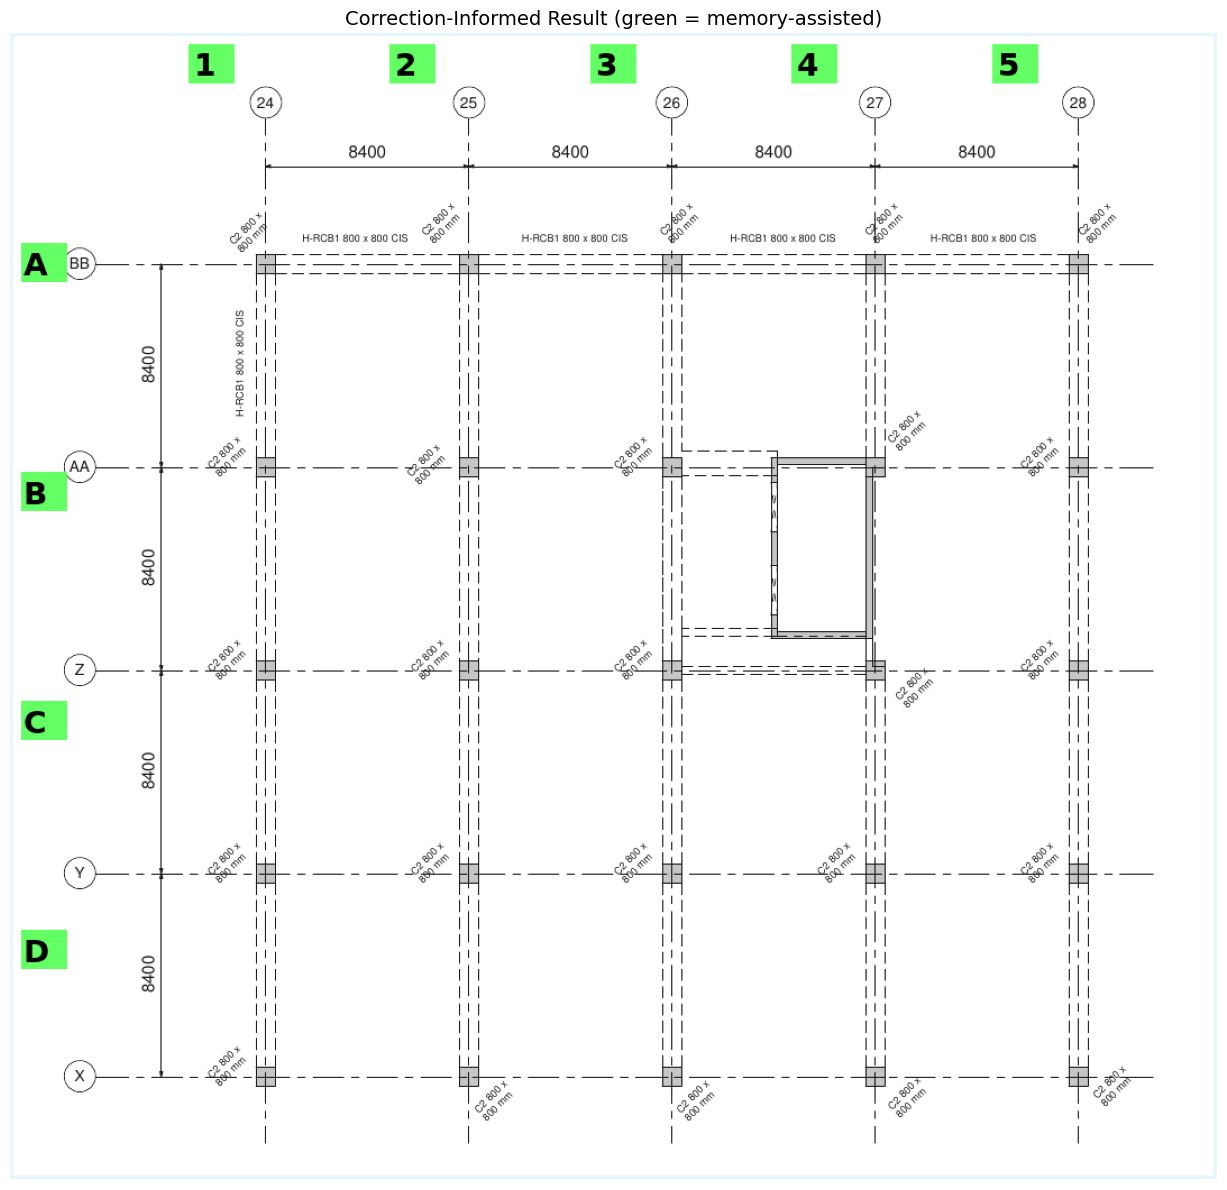

In [16]:
if not SEALION_ONLINE or not os.path.isfile(PDF_PATH):
    print("⚠ Skipping (SEA-LION offline or PDF missing).")
else:
    correction = tools.tool_memory_lookup(PDF_PATH)
    if not correction:
        print("⚠ No correction found for this PDF. Run Section 9 first.")
    else:
        print(f"📌 Correction active:")
        print(f"   Vertical:   {correction['vertical_labels']}")
        print(f"   Horizontal: {correction['horizontal_labels']}")
        if correction.get('notes'):
            print(f"   Notes: {correction['notes']}")
        print()
        print("Running full agent with correction memory...")
        print("=" * 60)
        corrected_result = agent.run(PDF_PATH, verbose=True)
        _state['corrected_result'] = corrected_result
        print("=" * 60)

        # Compare with original run from Section 5
        original = _state.get('full_result', {})
        print(f"\n{'Field':<25} {'Original (§5)':<35} {'Corrected (§10)':<35}")
        print("-" * 95)
        for field in ('total_grid_lines', 'vertical_labels', 'horizontal_labels', 'confidence'):
            a = original.get(field, 'N/A')
            b = corrected_result.get(field, 'N/A')
            if isinstance(a, list): a = ' '.join(a)
            if isinstance(b, list): b = ' '.join(b)
            changed = " ← changed" if str(a) != str(b) else ""
            print(f"{field:<25} {str(a):<35} {str(b):<35}{changed}")

        print()
        mem_flag = corrected_result.get('used_correction_memory', False)
        print(f"  used_correction_memory: {'✓ yes' if mem_flag else 'no'}")

        # Annotated image for corrected result
        try:
            from PIL import ImageDraw, ImageFont
            img_path = corrected_result.get('_rendered_image')
            if img_path:
                img = Image.open(img_path).convert('RGB')
                draw = ImageDraw.Draw(img)
                w, h = img.size
                try:
                    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 28)
                except IOError:
                    font = ImageFont.load_default()

                for i, lbl in enumerate(corrected_result.get('vertical_labels', [])):
                    n = len(corrected_result['vertical_labels'])
                    x = (w // (n + 1)) * (i + 1)
                    draw.rectangle([x-20, 10, x+20, 44], fill=(100,255,100))
                    draw.text((x-15, 12), lbl, fill=(0,0,0), font=font)

                for i, lbl in enumerate(corrected_result.get('horizontal_labels', [])):
                    n = len(corrected_result['horizontal_labels'])
                    y = (h // (n + 1)) * (i + 1)
                    draw.rectangle([10, y-17, 50, y+17], fill=(100,255,100))
                    draw.text((12, y-14), lbl, fill=(0,0,0), font=font)

                fig, ax = plt.subplots(figsize=(16, 12))
                ax.imshow(img)
                ax.set_title("Correction-Informed Result (green = memory-assisted)", fontsize=14)
                ax.axis('off')
                plt.tight_layout()
                plt.show()
        except Exception as e:
            print(f"(Annotation skipped: {e})")